## Question 9: Numerical Differentiation Using Interpolation

Write a Python program that accepts the following equally spaced data:

| X | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| Y | 1 | 3 | 7 | 13 | 21 |

The program should:

1. Construct the forward difference table.
2. Compute the first derivative f'(1) using Newton's Forward Difference Formula.
3. Construct the backward difference table.
4. Compute the first derivative f'(4) using Newton's Backward Difference Formula.
5. Compute the second derivative at the required point using the appropriate interpolation formula.
6. Display all intermediate difference tables and the numerical values of the derivatives.

In [16]:
import numpy as np
import pandas as pd
from IPython.display import display
import sympy as sp
import matplotlib.pyplot as plt
import math

In [17]:
#inititalising the actual value
x=np.array([0,1,2,3,4],dtype=float)
y=np.array([1,3,7,13,21],dtype=float)

# Q1) To create the forward difference table we take the value or accept the value then we know:<br>
Forward difference=y<sub>n+1</sub>-y<sub>n</sub><br>
We know that at each difference we reduce by 1 so we consider y we exactly construct 2d matrix to represent the forward difference.

In [18]:
def find_forward_diff(x,y)->np.ndarray:
    #this should give list forward differences
    n=len(x) #getting the length 
    forward=np.zeros((n,n))
    forward[:,0]=y #setting value of y
    #now calculating all the values of the forward difference below
    k=n
    for i in range(1,n): # as said above we know we get difference till the length of the dependent variable here
        #now for each of the delta
        for j in range(0,k-1):
            forward[j,i]=forward[j+1,i-1]-forward[j,i-1]
        k-=1
    return forward

forward=find_forward_diff(x,y)
forward_diff_table=pd.DataFrame(np.column_stack((x,forward)),columns=["x","y","Δ", "Δ²", "Δ³", "Δ⁴"])
display(forward_diff_table.style.format("{:.2f}").hide(axis="index"))
    


x,y,Δ,Δ²,Δ³,Δ⁴
0.00,1.00,2.00,2.00,0.00,0.00
1.00,3.00,4.00,2.00,0.00,0.00
2.00,7.00,6.00,2.00,0.00,0.00
3.00,13.00,8.00,0.00,0.00,0.00
4.00,21.00,0.00,0.00,0.00,0.00


# Q2) Compute f'(1) using above table<br>


## Newton's Forward Interpolation
- Step size: $h = x_{i+1}-x_i$
- $u=\dfrac{x-x_0}{h}$

The interpolation polynomial is:

$$f(x)=y_0 + u \Delta y_0 + \frac{u(u-1)}{2!} \Delta^2 y_0 + \frac{u(u-1)(u-2)}{3!} \Delta^3 y_0 + \frac{u(u-1)(u-2)(u-3)}{4!} \Delta^4 y_0 + \cdots$$

---

## Newton's Forward Differentiation

Since:

$$u=\frac{x-x_0}{h}$$

$$\boxed{\frac{dy}{dx} = \frac{1}{h} \left[ \Delta y_0 + \frac{2u-1}{2} \Delta^2 y_0 + \frac{3u^2-6u+2}{6} \Delta^3 y_0 + \frac{4u^3-18u^2+22u-6}{24} \Delta^4 y_0 + \cdots \right]}$$

## At $x=x_0$ (i.e. $u=0$)

$$\boxed{\left(\frac{dy}{dx}\right)_{x=x_0} = \frac{1}{h} \left[ \Delta y_0 - \frac{1}{2} \Delta^2 y_0 + \frac{1}{3} \Delta^3 y_0 - \frac{1}{4} \Delta^4 y_0 + \cdots \right]}$$



In [19]:

#We know x0=1 so f'(1) we use the formula directly
def newton_fdifferentiation(forward_diff_table,x):
    h=forward_diff_table["x"].iloc[1]-forward_diff_table["x"].iloc[0]
    x0_index=forward_diff_table[forward_diff_table["x"]==x].index[0]
    #i will be writing more of a general case here
    x0=forward_diff_table["x"].iloc[x0_index]
    p_val=(x-x0)/(h)
    p=sp.symbols("p")
    #now implementing the value
    expr=1
    sum=0
    print("The derivative of each p term of interpolation formula would be:\n")
    for i,col in enumerate(range(2,len(forward_diff_table.columns))):
        for j in range(i+1):
            expr*=(p-j)
        deriv=sp.diff(expr,p)
        value=deriv.subs(p,p_val)
        print(f"f(p)={expr} where f'(x)={deriv} and f'({p_val})={value}!")

        sum+=(1/math.factorial(i+1))*forward_diff_table.iloc[x0_index,col]*value
        expr=1
    diff=sum/h
    return diff



Now calling the diff function at x=1 which is x=x<sub>0</sub> condition.

In [20]:
f_derv_at_1=newton_fdifferentiation(forward_diff_table,x=1)
print("================================================================")#these were added by me mahesh not vibe coded ;)
print(f"The derivative of f(x) at 1 is, f'(1)={f_derv_at_1:.5f}!")
print("================================================================")


The derivative of each p term of interpolation formula would be:

f(p)=p where f'(x)=1 and f'(0.0)=1!
f(p)=p*(p - 1) where f'(x)=2*p - 1 and f'(0.0)=-1!
f(p)=p*(p - 2)*(p - 1) where f'(x)=p*(p - 2) + p*(p - 1) + (p - 2)*(p - 1) and f'(0.0)=2.00000000000000!
f(p)=p*(p - 3)*(p - 2)*(p - 1) where f'(x)=p*(p - 3)*(p - 2) + p*(p - 3)*(p - 1) + p*(p - 2)*(p - 1) + (p - 3)*(p - 2)*(p - 1) and f'(0.0)=-6.00000000000000!
The derivative of f(x) at 1 is, f'(1)=3.00000!


# Q3) Constructing backward difference table:<br>
Backward difference=y<sub>n</sub>-y<sub>n-1</sub><br>
We know that at each difference we reduce by 1 so we consider y we exactly construct 2d matrix to represent the backward difference.

In [21]:

def find_backward_diff(x, y) -> np.ndarray:
    n = len(x)
    backward = np.zeros((n, n))
    backward[:, 0] = y

    for i in range(1, n):
        for j in range(i, n):
            backward[j, i] = backward[j, i - 1] - backward[j - 1, i - 1]

    return backward


backward = find_backward_diff(x, y)

cols = ["x", "y", "∇", "∇²", "∇³", "∇⁴"][: len(x) + 1]
backward_diff_table = pd.DataFrame(np.column_stack((x, backward)), columns=cols)

display(backward_diff_table.style.format("{:.2f}").hide(axis="index"))

x,y,∇,∇²,∇³,∇⁴
0.00,1.00,0.00,0.00,0.00,0.00
1.00,3.00,2.00,0.00,0.00,0.00
2.00,7.00,4.00,2.00,0.00,0.00
3.00,13.00,6.00,2.00,0.00,0.00
4.00,21.00,8.00,2.00,0.00,0.00


# Q4) Compute f'(4) using Netwon's backward differentiation forumula<br>
## 1. Position Parameter $p$
When working backward from a base point $x_n$ near the end of the table:

$$p = \frac{x - x_n}{h}$$

* $x$: target evaluation point
* $x_n$: baseline point from the bottom of the table
* $h$: step size between consecutive $x$ values ($x_{i+1} - x_i$)

---

## 2. Backward Difference Definition
For any column $k$ and row $i$:

$$\nabla^k y_i = \nabla^{k-1} y_i - \nabla^{k-1} y_{i-1}$$

* $\nabla y_n = y_n - y_{n-1}$
* $\nabla^2 y_n = \nabla y_n - \nabla y_{n-1}$

---

## 3. Newton’s Backward Interpolation Formula
To interpolate $f(x)$ at any arbitrary point:

$$f(x) = y_n + p \nabla y_n + \frac{p(p + 1)}{2!} \nabla^2 y_n + \frac{p(p + 1)(p + 2)}{3!} \nabla^3 y_n + \dots + \frac{\prod_{j=0}^{k-1} (p + j)}{k!} \nabla^k y_n$$

---

## 4. First Derivative $\left(\frac{dy}{dx}\right)$

### General Case (for any $p$)
$$\frac{dy}{dx} = \frac{1}{h} \left[ \nabla y_n + \frac{2p + 1}{2} \nabla^2 y_n + \frac{3p^2 + 6p + 2}{6} \nabla^3 y_n + \frac{2p^3 + 9p^2 + 11p + 3}{12} \nabla^4 y_n + \dots \right]$$

### Special Case: At the base point $x = x_n$ ($p = 0$)
$$\left. \frac{dy}{dx} \right|_{x=x_n} = \frac{1}{h} \left[ \nabla y_n + \frac{1}{2} \nabla^2 y_n + \frac{1}{3} \nabla^3 y_n + \frac{1}{4} \nabla^4 y_n + \dots \right]$$

> **Key Difference:** Unlike forward differentiation (which alternates signs $+ - + -$), **all terms in backward differentiation at $p = 0$ are positive**!

---


In [22]:
def newton_bdifferentiation_firstOrder(backward_diff_table, x):
    h = backward_diff_table["x"].iloc[1] - backward_diff_table["x"].iloc[0]
    xn_index = backward_diff_table[backward_diff_table["x"] == x].index[0]

    xn = backward_diff_table["x"].iloc[xn_index]
    p_val = (x - xn) / h
    p = sp.symbols("p")

    expr = 1
    total_sum = 0
    print("The derivative of each p term of interpolation formula would be:\n")

    for i, col in enumerate(range(2, len(backward_diff_table.columns))):
        # Build polynomial p*(p+1)*(p+2)...
        for j in range(i + 1):
            expr *= p + j

        deriv = sp.diff(expr, p)
        value = float(deriv.subs(p, p_val))
        print(f"f(p)={expr} where f'(x)={deriv} and f'({p_val})={value}!")

        total_sum += (
            1 / math.factorial(i + 1)
        ) * backward_diff_table.iloc[xn_index, col] * value
        expr = 1

    diff = total_sum / h
    return diff

Now we calculate the value of f'(4):

In [23]:
f_derv_at_4=newton_bdifferentiation_firstOrder(backward_diff_table,x=4)
print("================================================================")
print(f"The derivative of f(x) at 4 is, f'(4)={f_derv_at_4:.5f}!")
print("================================================================")


The derivative of each p term of interpolation formula would be:

f(p)=p where f'(x)=1 and f'(0.0)=1.0!
f(p)=p*(p + 1) where f'(x)=2*p + 1 and f'(0.0)=1.0!
f(p)=p*(p + 1)*(p + 2) where f'(x)=p*(p + 1) + p*(p + 2) + (p + 1)*(p + 2) and f'(0.0)=2.0!
f(p)=p*(p + 1)*(p + 2)*(p + 3) where f'(x)=p*(p + 1)*(p + 2) + p*(p + 1)*(p + 3) + p*(p + 2)*(p + 3) + (p + 1)*(p + 2)*(p + 3) and f'(0.0)=6.0!
The derivative of f(x) at 4 is, f'(4)=9.00000!


# Q5) To  calculate second order derivative using appropirate formula:<br>
## Second Derivative $\left(\frac{d^2 y}{dx^2}\right)$

### General Case (for any $p$)
$$\frac{d^2 y}{dx^2} = \frac{1}{h^2} \left[ \nabla^2 y_n + (p + 1) \nabla^3 y_n + \frac{6p^2 + 18p + 11}{12} \nabla^4 y_n + \dots \right]$$

### Special Case: At $x = x_n$ ($p = 0$)
$$\left. \frac{d^2 y}{dx^2} \right|_{x=x_n} = \frac{1}{h^2} \left[ \nabla^2 y_n + \nabla^3 y_n + \frac{11}{12} \nabla^4 y_n + \dots \right]$$

In [24]:
def newton_bdifferentiation_seconOrder(backward_diff_table, x):
    h = backward_diff_table["x"].iloc[1] - backward_diff_table["x"].iloc[0]
    xn_index = backward_diff_table[backward_diff_table["x"] == x].index[0]

    xn = backward_diff_table["x"].iloc[xn_index]
    p_val = (x - xn) / h
    p = sp.symbols("p")

    expr = 1
    total_sum = 0
    print("The expression we get from differentiating each p term from the interpolation formula would be:\n")
    for i, col in enumerate(range(2, len(backward_diff_table.columns))):
        # Build polynomial p*(p+1)*(p+2)...
        for j in range(i + 1):
            expr *= p + j

        deriv_1 = sp.diff(expr, p)
        deriv=sp.diff(deriv_1,p)
        value = float(deriv.subs(p, p_val))

        print(f"f(p)={expr} where f'(x)={deriv_1} while f\"(p)={deriv} and f'({p_val})={value}!")

        total_sum += (
            1 / math.factorial(i + 1)
        ) * backward_diff_table.iloc[xn_index, col] * value
        expr = 1

    diff = total_sum /(h**2)
    return diff

In [25]:
f_derv_at_4=newton_bdifferentiation_seconOrder(backward_diff_table,x=4)
print("================================================================") #these were added by me mahesh not ai read this before you judge! 
print(f"The second derivative of f(x) at 4 is, f\"(4)={f_derv_at_4:.5f}!")
print("================================================================")
f_derv_at_2=newton_bdifferentiation_seconOrder(backward_diff_table,x=2)
print("================================================================")
print(f"The second derivative of f(x) at 2 is, f\"(2)={f_derv_at_2:.5f}!")
print("================================================================")


The expression we get from differentiating each p term from the interpolation formula would be:

f(p)=p where f'(x)=1 while f"(p)=0 and f'(0.0)=0.0!
f(p)=p*(p + 1) where f'(x)=2*p + 1 while f"(p)=2 and f'(0.0)=2.0!
f(p)=p*(p + 1)*(p + 2) where f'(x)=p*(p + 1) + p*(p + 2) + (p + 1)*(p + 2) while f"(p)=6*p + 6 and f'(0.0)=6.0!
f(p)=p*(p + 1)*(p + 2)*(p + 3) where f'(x)=p*(p + 1)*(p + 2) + p*(p + 1)*(p + 3) + p*(p + 2)*(p + 3) + (p + 1)*(p + 2)*(p + 3) while f"(p)=2*p*(p + 1) + 2*p*(p + 2) + 2*p*(p + 3) + 2*(p + 1)*(p + 2) + 2*(p + 1)*(p + 3) + 2*(p + 2)*(p + 3) and f'(0.0)=22.0!
The second derivative of f(x) at 4 is, f"(4)=2.00000!
The expression we get from differentiating each p term from the interpolation formula would be:

f(p)=p where f'(x)=1 while f"(p)=0 and f'(0.0)=0.0!
f(p)=p*(p + 1) where f'(x)=2*p + 1 while f"(p)=2 and f'(0.0)=2.0!
f(p)=p*(p + 1)*(p + 2) where f'(x)=p*(p + 1) + p*(p + 2) + (p + 1)*(p + 2) while f"(p)=6*p + 6 and f'(0.0)=6.0!
f(p)=p*(p + 1)*(p + 2)*(p + 3) wher

# Q6) Display all intermediate tables and display numerical values of derivates:<br>
All intermediate tables have been generated above, placed directly under their respective headings, and the derivative values are also displayed alongside them.

In [ ]:
#getting values of derivative 
derv=np.zeros_like(x)
second_order=np.zeros_like(x)
for i in range(len(x)):
    derv[i]=newton_fdifferentiation(forward_diff_table,x[i])
    second_order[i]=newton_bdifferentiation_seconOrder(backward_diff_table,x[i])

In [54]:
print(f"The first derivatives for all points woudl be: {derv}!\n")
print(f"The second derivatives for all the points would be; {second_order}!")

The first derivatives for all points woudl be: [1. 3. 5. 8. 0.]!

The second derivatives for all the points would be; [0. 0. 2. 2. 2.]!


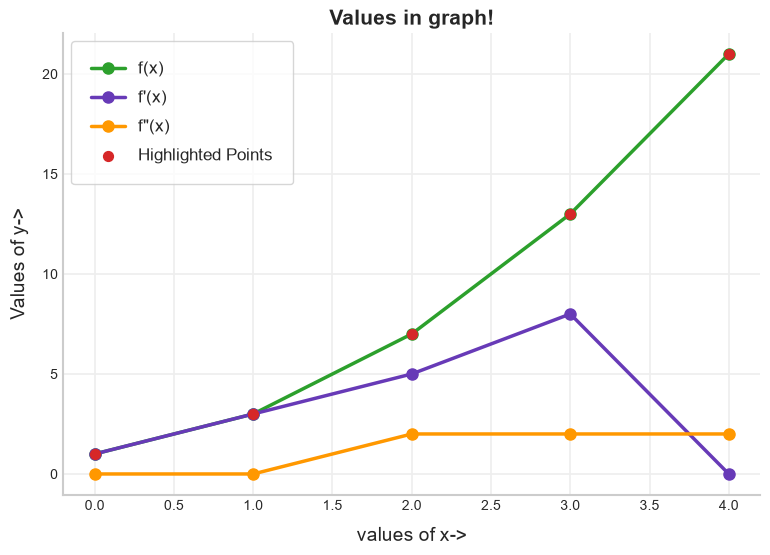

In [56]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(9, 6))
plt.plot(x, y, color="#2ca02c", linewidth=2.5, 
         marker='o', markersize=8, label="f(x)")
plt.plot(x,derv,color="#673ab7",linewidth=2.5, 
         marker='o', markersize=8,label="f'(x)")
plt.plot(x,second_order,color="#ff9800",linewidth=2.5, 
         marker='o', markersize=8,label="f\"(x)")
plt.scatter(x, y, color="#d62728", s=50, zorder=5, label="Highlighted Points")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(color='#eeeeee', linestyle='-', linewidth=1.2)

ax.legend(frameon=True, facecolor='white', edgecolor='#cccccc', 
          fontsize=12, loc='upper left', borderpad=1.2, labelspacing=0.8)
plt.xlabel("values of x->",fontsize=14, labelpad=10)
plt.ylabel("Values of y->",fontsize=14, labelpad=10)
plt.title("Values in graph!",fontsize=15,fontweight='bold',)
plt.show()

<p align="center">Thank you!!</p>